##Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")

##Load Data

In [3]:

#colab is google server its cant see local files ,so it acts as bridge between local files and server to ove from system to colab
from google.colab import files

#After this runs, your file is stored in a folder called /content/
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gopichandboosa","key":"49f5bd9ca20dcbe4599d9162e43de3ce"}'}

In [4]:
#mkdir means "make directory" (create a folder). The -p ensures it doesn't crash if the folder already exists. The ~/.kaggle means create a hidden folder named .kaggle in the "home" directory.
!mkdir -p ~/.kaggle #~	Tilde	"The Home Folder" (Where the system keeps user-specific settings).
#.	Dot	"Hidden" (If a file starts with a dot, it is invisible to normal users).
#/	Slash	"Inside" (Used to separate folders).
!cp kaggle.json ~/.kaggle/ #copy kaggle.json into hidden folder
!chmod 600 ~/.kaggle/kaggle.json #change mode,600-Only the owner (you/this notebook) can read or write this file. No one else on the server can touch it."


In [5]:
# Download SMS Spam Collection dataset
!kaggle datasets download -d uciml/sms-spam-collection-dataset

# Unzip into a folder
!unzip sms-spam-collection-dataset.zip -d sms_spam_data



Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
  0% 0.00/211k [00:00<?, ?B/s]
100% 211k/211k [00:00<00:00, 486MB/s]
Archive:  sms-spam-collection-dataset.zip
  inflating: sms_spam_data/spam.csv  


In [9]:
# The original data loading failed, so we ensure 'df' is defined here
# as the dataset is now available at 'sms_spam_data/spam.csv'
try:
    df = pd.read_csv('sms_spam_data/spam.csv', encoding='latin-1')
    df = df[['v1', 'v2']]
    df.columns = ['label', 'message']
    df = df.dropna()
    df['label'] = df['label'].map({'spam': 1, 'ham': 0})
    print("✓ Dataset loaded successfully within EDA cell!")
except FileNotFoundError:
    print("❌ ERROR: 'sms_spam_data/spam.csv' not found. Please ensure it's downloaded and unzipped.")
    raise # Re-raise the error to stop execution if file is still missing

# Add feature columns
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print("\nMessage Statistics:")
print(df.groupby('label')[['message_length', 'word_count']].describe().round(2))

# Create EDA visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Class distribution
label_counts = df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0, 0].bar(['Ham', 'Spam'], [label_counts[0], label_counts[1]],
               color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=11)
for i, v in enumerate([label_counts[0], label_counts[1]]):
    axes[0, 0].text(i, v + 50, str(v), ha='center', va='bottom',
                    fontweight='bold', fontsize=12)

# 2. Message length distribution
axes[0, 1].hist([df[df['label']==0]['message_length'],
                df[df['label']==1]['message_length']],
               bins=50, label=['Ham', 'Spam'], color=colors, alpha=0.7)
axes[0, 1].set_title('Message Length Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Message Length', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend(fontsize=10)

# 3. Word count distribution
axes[1, 0].hist([df[df['label']==0]['word_count'],
                df[df['label']==1]['word_count']],
               bins=40, label=['Ham', 'Spam'], color=colors, alpha=0.7)
axes[1, 0].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Word Count', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].legend(fontsize=10)

# 4. Box plots
box_data = [df[df['label']==0]['message_length'],
            df[df['label']==1]['message_length']]
bp = axes[1, 1].boxplot(box_data, labels=['Ham', 'Spam'], patch_artist=True,
                        boxprops=dict(linewidth=1.5),
                        medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e74c3c')
bp['boxes'][1].set_alpha(0.7)
axes[1, 1].set_title('Message Length Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Message Length', fontsize=11)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
print("✓ EDA visualization saved: 'eda_analysis.png'")
plt.close()

✓ Dataset loaded successfully within EDA cell!

Message Statistics:
      message_length                                                   \
               count    mean    std   min    25%    50%    75%    max   
label                                                                   
0             4825.0   71.02  58.02   2.0   33.0   52.0   92.0  910.0   
1              747.0  138.87  29.18  13.0  132.5  149.0  157.0  224.0   

      word_count                                              
           count   mean    std  min   25%   50%   75%    max  
label                                                         
0         4825.0  14.20  11.42  1.0   7.0  11.0  19.0  171.0  
1          747.0  23.85   5.81  2.0  22.0  25.0  28.0   35.0  
✓ EDA visualization saved: 'eda_analysis.png'


##Text PreProcessing

In [10]:
print("Preprocessing Text Data...")

def preprocess_text(text):
    """Clean and normalize text."""
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove phone numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Apply preprocessing
df['processed_message'] = df['message'].apply(preprocess_text)

print("✓ Text preprocessing completed")
print("\nExample:")
print(f"  Original:  {df['message'].iloc[0]}")
print(f"  Processed: {df['processed_message'].iloc[0]}")


Preprocessing Text Data...
✓ Text preprocessing completed

Example:
  Original:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Processed: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


##Feature Engineering(TF-IDF)

In [11]:

print("Feature Engineering with TF-IDF...")

# Split data
X = df['processed_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"  Training set: {len(X_train)} messages")
print(f"  Test set: {len(X_test)} messages")

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=3000,      # Top 3000 features
    min_df=5,               # Word must appear in at least 5 documents
    max_df=0.7,             # Word must appear in at most 70% of documents
    ngram_range=(1, 2),     # Use unigrams and bigrams
    stop_words='english'    # Remove common English words
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"✓ TF-IDF vectorization completed")
print(f"  Feature matrix shape: {X_train_tfidf.shape}")
print(f"  Number of features: {len(tfidf.get_feature_names_out())}")

# Analyze top features
feature_names = tfidf.get_feature_names_out()

spam_indices = np.array(y_train == 1)
ham_indices = np.array(y_train == 0)

spam_tfidf = np.asarray(X_train_tfidf[spam_indices].mean(axis=0)).flatten()
ham_tfidf = np.asarray(X_train_tfidf[ham_indices].mean(axis=0)).flatten()

top_spam_idx = spam_tfidf.argsort()[-20:][::-1]
top_ham_idx = ham_tfidf.argsort()[-20:][::-1]

# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

spam_words = [feature_names[i] for i in top_spam_idx[:15]]
spam_scores = [spam_tfidf[i] for i in top_spam_idx[:15]]
axes[0].barh(range(15), spam_scores, color='#e74c3c', alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(spam_words, fontsize=10)
axes[0].set_xlabel('Mean TF-IDF Score', fontsize=11, fontweight='bold')
axes[0].set_title('Top 15 Spam Indicators', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

ham_words = [feature_names[i] for i in top_ham_idx[:15]]
ham_scores = [ham_tfidf[i] for i in top_ham_idx[:15]]
axes[1].barh(range(15), ham_scores, color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(ham_words, fontsize=10)
axes[1].set_xlabel('Mean TF-IDF Score', fontsize=11, fontweight='bold')
axes[1].set_title('Top 15 Ham Indicators', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_features.png', dpi=300, bbox_inches='tight')
print("✓ Feature importance saved: 'top_features.png'")
plt.close()


Feature Engineering with TF-IDF...
  Training set: 4457 messages
  Test set: 1115 messages
✓ TF-IDF vectorization completed
  Feature matrix shape: (4457, 1601)
  Number of features: 1601
✓ Feature importance saved: 'top_features.png'


##Model Training

In [12]:
print("Training Machine Learning Models...")

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n  Training {name}...")

    # Train
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)
    y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1')

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"    Accuracy:  {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall:    {recall:.4f}")
    print(f"    F1-Score:  {f1:.4f}")

print("\n✓ All models trained successfully!")


Training Machine Learning Models...

  Training Naive Bayes...
    Accuracy:  0.9740
    Precision: 0.9762
    Recall:    0.8255
    F1-Score:  0.8945

  Training Logistic Regression...
    Accuracy:  0.9686
    Precision: 1.0000
    Recall:    0.7651
    F1-Score:  0.8669

  Training SVM...
    Accuracy:  0.9812
    Precision: 0.9923
    Recall:    0.8658
    F1-Score:  0.9247

  Training Random Forest...
    Accuracy:  0.9767
    Precision: 0.9767
    Recall:    0.8456
    F1-Score:  0.9065

✓ All models trained successfully!


##Model Evaluation

In [13]:
print("Evaluating Models...")

# Create comprehensive evaluation plot
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Model comparison bar chart
ax1 = fig.add_subplot(gs[0, :])
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(results))
width = 0.2
colors_metrics = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']

for i, metric in enumerate(metrics):
    values = [results[name][metric] for name in results]
    ax1.bar(x + i*width, values, width, label=metric.replace('_', ' ').title(),
            alpha=0.8, color=colors_metrics[i], edgecolor='black', linewidth=1)

ax1.set_xlabel('Models', fontweight='bold', fontsize=12)
ax1.set_ylabel('Score', fontweight='bold', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(results.keys(), fontsize=11)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0.9, 1.01])

# 2-5. Confusion matrices
for idx, (name, result) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1 + idx//2, idx%2])
    cm = result['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=['Ham', 'Spam'],
               yticklabels=['Ham', 'Spam'],
               cbar_kws={'label': 'Count'},
               annot_kws={'fontsize': 12, 'fontweight': 'bold'})

    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

# 6. ROC Curves
ax6 = fig.add_subplot(gs[2, :])
for name, result in results.items():
    if result['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        auc = roc_auc_score(y_test, result['y_pred_proba'])
        ax6.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2.5)

ax6.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
ax6.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
ax6.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
ax6.set_title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold', pad=20)
ax6.legend(loc='lower right', fontsize=10)
ax6.grid(alpha=0.3, linestyle='--')

plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
print("✓ Model evaluation saved: 'model_evaluation.png'")
plt.close()

# Print detailed reports
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

for name, result in results.items():
    print(f"\n{name}:")
    print("-" * 80)
    print(classification_report(y_test, result['y_pred'],
                               target_names=['Ham', 'Spam'], digits=4))

Evaluating Models...
✓ Model evaluation saved: 'model_evaluation.png'

DETAILED CLASSIFICATION REPORTS

Naive Bayes:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

         Ham     0.9737    0.9969    0.9852       966
        Spam     0.9762    0.8255    0.8945       149

    accuracy                         0.9740      1115
   macro avg     0.9750    0.9112    0.9399      1115
weighted avg     0.9740    0.9740    0.9731      1115


Logistic Regression:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

         Ham     0.9650    1.0000    0.9822       966
        Spam     1.0000    0.7651    0.8669       149

    accuracy                         0.9686      1115
   macro avg     0.9825    0.8826    0.9246      1115
weighted avg     0.9697    0.9686    0.9668      1115


SVM:
---------------------------------------

##Save Results

In [14]:

print("Saving Results...")

# Create summary report
report_lines = []
report_lines.append("="*80)
report_lines.append("SMS SPAM DETECTION - MODEL PERFORMANCE REPORT")
report_lines.append("="*80)
report_lines.append("")
report_lines.append(f"Dataset: SMS Spam Collection")
report_lines.append(f"Total Messages: {len(df)}")
report_lines.append(f"Training Messages: {len(X_train)}")
report_lines.append(f"Test Messages: {len(X_test)}")
report_lines.append("")

report_lines.append("MODEL PERFORMANCE SUMMARY")
report_lines.append("-"*80)
report_lines.append(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
report_lines.append("-"*80)

for name, result in results.items():
    report_lines.append(
        f"{name:<20} "
        f"{result['accuracy']:<12.4f} "
        f"{result['precision']:<12.4f} "
        f"{result['recall']:<12.4f} "
        f"{result['f1_score']:<12.4f}"
    )

report_lines.append("")
report_lines.append("CROSS-VALIDATION RESULTS (5-Fold)")
report_lines.append("-"*80)
report_lines.append(f"{'Model':<20} {'Mean F1':<15} {'Std Dev':<15}")
report_lines.append("-"*80)

for name, result in results.items():
    report_lines.append(
        f"{name:<20} "
        f"{result['cv_mean']:<15.4f} "
        f"{result['cv_std']:<15.4f}"
    )

# Best model
best_model = max(results.items(), key=lambda x: x[1]['f1_score'])
report_lines.append("")
report_lines.append("BEST PERFORMING MODEL")
report_lines.append("-"*80)
report_lines.append(f"Model: {best_model[0]}")
report_lines.append(f"F1-Score: {best_model[1]['f1_score']:.4f}")
report_lines.append(f"Accuracy: {best_model[1]['accuracy']:.4f}")
report_lines.append(f"Precision: {best_model[1]['precision']:.4f}")
report_lines.append(f"Recall: {best_model[1]['recall']:.4f}")
report_lines.append("")
report_lines.append("="*80)

report_text = "\n".join(report_lines)

with open('model_performance_report.txt', 'w') as f:
    f.write(report_text)

print("✓ Performance report saved: 'model_performance_report.txt'")



Saving Results...
✓ Performance report saved: 'model_performance_report.txt'


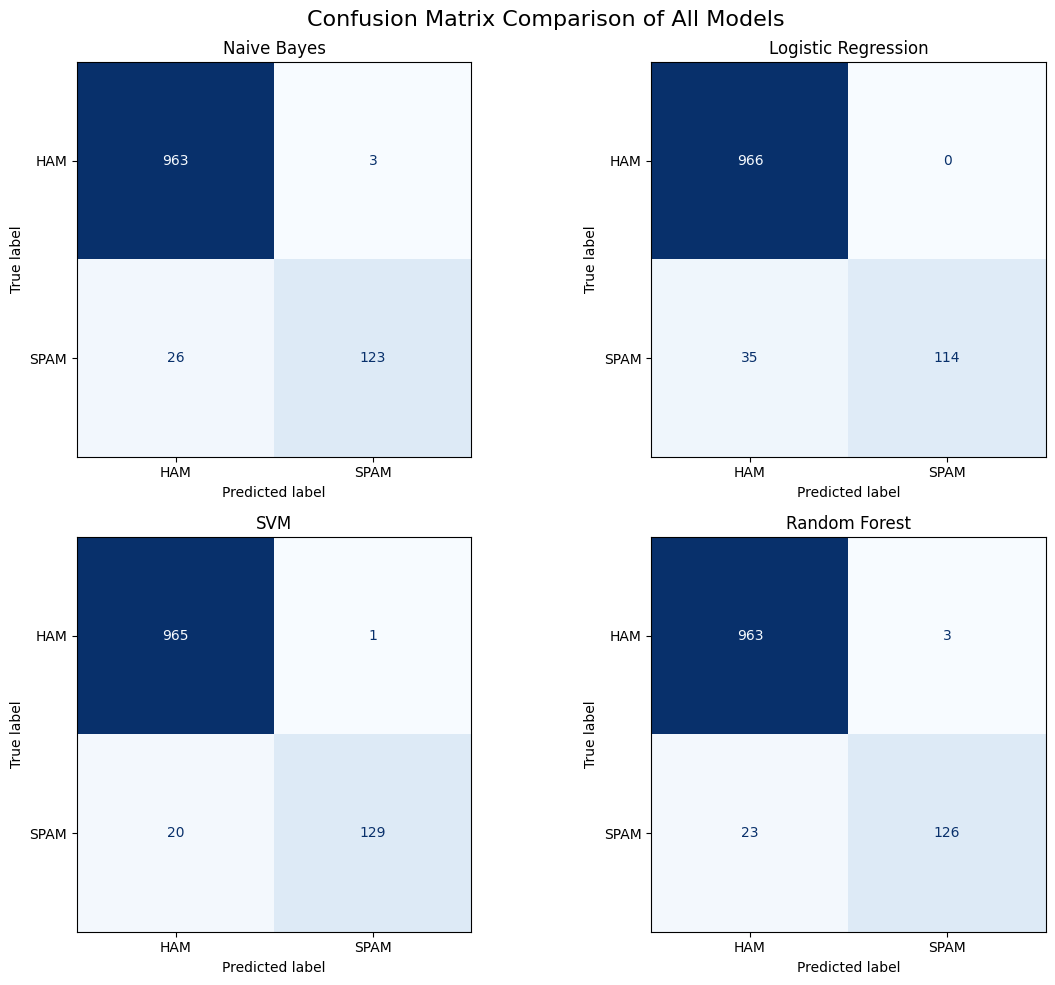

In [22]:
models = list(results.keys())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, models):
    model = results[model_name]['model']

    # Predictions
    # Corrected: Use X_test_tfidf instead of X_test for prediction
    y_pred = model.predict(X_test_tfidf)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['HAM', 'SPAM']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(model_name)

plt.suptitle('Confusion Matrix Comparison of All Models', fontsize=16)
plt.tight_layout()
plt.show()

##Test Predictions

In [15]:
print("Test Your Own SMS Messages")
print("Type 'exit' to stop\n")

def predict_message(message, model_name='Logistic Regression'):
    """Predict if a message is spam or ham."""

    # Preprocess
    processed = preprocess_text(message)
    vectorized = tfidf.transform([processed])

    # Load model
    model = results[model_name]['model']
    prediction = model.predict(vectorized)[0]

    # Probability (if supported)
    spam_prob = None
    if hasattr(model, 'predict_proba'):
        spam_prob = model.predict_proba(vectorized)[0][1]

    return prediction, spam_prob


# Interactive loop
while True:
    user_message = input("Enter SMS message: ")

    if user_message.lower() == 'exit':
        print("Exiting prediction mode.")
        break

    pred, prob = predict_message(user_message)

    print("\nResult:")
    print("Prediction:", "SPAM 🚨" if pred == 1 else "HAM ✅")

    if prob is not None:
        print(f"Spam Confidence: {prob:.2%}")

    print("-" * 60)


Test Your Own SMS Messages
Type 'exit' to stop

Enter SMS message: Meeting rescheduled to 3pm. See you then.

Result:
Prediction: HAM ✅
Spam Confidence: 9.11%
------------------------------------------------------------
Enter SMS message: You have been selected for a FREE vacation to the Bahamas!

Result:
Prediction: SPAM 🚨
Spam Confidence: 59.18%
------------------------------------------------------------
Enter SMS message: exit
Exiting prediction mode.


##Sample messages


In [16]:
# Test with sample messages
test_messages = [
    "Congratulations! You've won a $1000 gift card. Click here to claim now!",
    "Hey, are we still on for lunch tomorrow at 1pm?",
    "URGENT: Your bank account has been compromised. Call 555-0123 immediately!",
    "Thanks for your help today. Really appreciate it!",
    "FREE entry to win an iPhone! Text WIN to 87121 now!",
    "Can you pick up some milk on your way home?",
    "You have been selected for a FREE vacation to the Bahamas!",
    "Meeting rescheduled to 3pm. See you then."
    'Hey how are you doing today',
    'Can you pick up some milk on your way home',
    'Meeting at 3pm tomorrow',
    'Thanks for your help earlier',
    'Did you see the game last night?',
    'Let me know when you get here',
    'Looking forward to seeing you soon',
    'Great work on the presentation today'
]